# Optional Lab - Multi-class Classification


## 1.1 目标
在本实验中，你将探索一个使用神经网络进行多分类的示例。
<figure>
 <img src="../work/images/C2_W2_mclass_header.png"   style="width500px;height:200px;">
</figure>


## 1.2 工具
你将使用一些绘图程序。这些程序存储在本目录下的`lab_utils_multiclass_TF.py`中。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from sklearn.datasets import make_blobs
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
np.set_printoptions(precision=2)
from lab_utils_multiclass_TF import *
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

# 2.0 多类别分类
神经网络常被用于对数据进行分类。以下是神经网络的一些示例：
- 输入照片，并将照片中的对象分类为{狗、猫、马、其他}
- 输入一个句子，并对其元素的“词性”进行分类：{名词、动词、形容词等}  

这类网络的最后一层会有多个单元。每个输出都与一个类别相关联。当将一个输入示例应用于网络时，值最高的输出就是预测的类别。如果将输出应用于softmax函数，softmax的输出将给出输入属于每个类别的概率。 

在本实验中，你将看到一个在TensorFlow中构建多类别网络的示例。然后，我们将研究神经网络是如何进行预测的。  

让我们从创建一个四类数据集开始。 

## 2.1 准备并可视化数据
我们将使用Scikit-Learn的`make_blobs`函数生成一个包含4个类别的训练数据集，如下图所示。

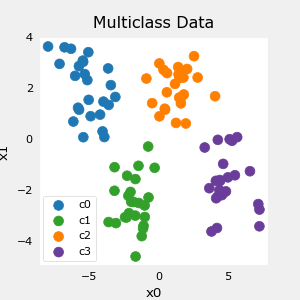

In [2]:
# make 4-class dataset for classification
classes = 4
m = 100
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0
X_train, y_train = make_blobs(n_samples=m, centers=centers, cluster_std=std, random_state=30)
plt_mc(X_train,y_train,classes, centers, std=std)

每个点代表一个训练样本。坐标轴（x0, x1）为输入，颜色代表该样本所属的类别。模型训练完成后，将输入一个新样本（x0, x1），并预测其类别。  

In [3]:
# show classes in data set
print(f"unique classes {np.unique(y_train)}")
# show how classes are represented
print(f"class representation {y_train[:10]}")
# show shapes of our dataset
print(f"shape of X_train: {X_train.shape}, shape of y_train: {y_train.shape}")

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of X_train: (100, 2), shape of y_train: (100,)


## 2.2 Model
<img align="Right" src="../work/images/C2_W2_mclass_lab_network.PNG"  style=" width:350px; padding: 10px 20px ; ">

本实验将使用如图所示的两层网络。与二分类网络不同，该网络有四个输出，每个类别对应一个输出。给定一个输入样本，值最高的输出即为该输入的预测类别。   

以下是在TensorFlow中构建此网络的示例。请注意，输出层使用的是“线性”激活函数，而非“softmax”激活函数。虽然可以在输出层加入softmax函数，但在训练期间将线性输出传递给损失函数在数值上会更稳定。如果该模型用于预测概率，那么可以在预测时应用softmax函数。 

In [4]:
tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        Dense(2, activation = 'relu',   name = "L1"),
        Dense(4, activation = 'linear', name = "L2")
    ]
)

以下语句用于编译和训练网络。将`from_logits=True`作为参数传递给损失函数，表示输出激活是线性的，而非softmax激活。 

In [5]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X_train,y_train,
    epochs=200
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1139  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0375
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9771
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9235 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8738
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8274
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7834
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7411
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7008
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6612 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6242
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5894
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5570
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5269
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4988
Epoch 16/200
4/4 ━━━━━━━━━━━━

模型训练完成后，我们可以看看模型是如何对训练数据进行分类的。

184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step


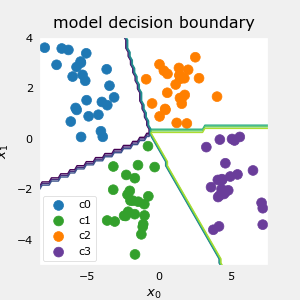

In [6]:
plt_cat_mc(X_train, y_train, model, classes)

上述内容中，决策边界展示了模型是如何划分输入空间的。这个非常简单的模型在对训练数据进行分类时没有遇到任何问题。它是如何做到的呢？让我们更详细地研究一下这个网络。

下面，我们将从模型中提取训练好的权重，并利用这些权重绘制每个网络单元的函数。再往下，会有对结果更详细的解释。    
要成功使用神经网络，你并不需要了解这些细节，但了解这些细节可能有助于更直观地理解各层是如何组合起来解决分类问题的。 

In [7]:
# 从第一层收集训练好的参数
l1 = model.get_layer("L1")
W1,b1 = l1.get_weights()

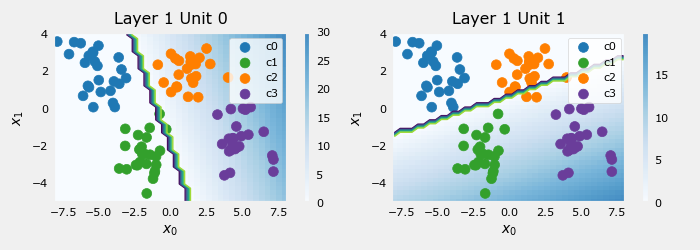

In [8]:
# 绘制第一层的函数图像
plt_layer_relu(X_train, y_train.reshape(-1,), W1, b1, classes)

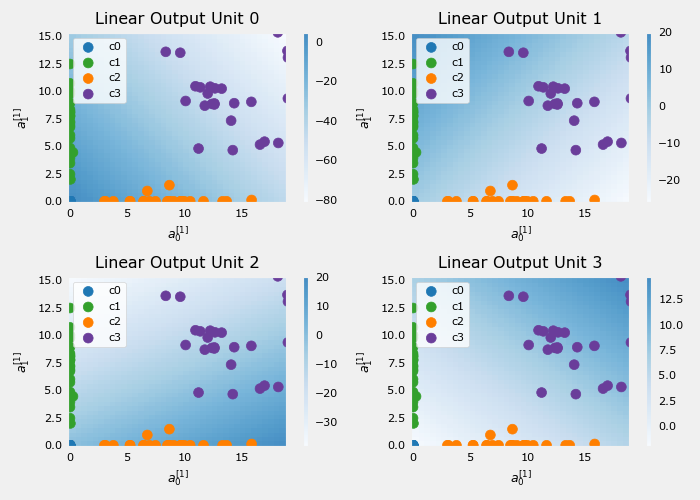

In [9]:
# 从输出层收集训练好的参数
l2 = model.get_layer("L2")
W2, b2 = l2.get_weights()

# 创建“新特征”，即L1变换后的训练示例
Xl2 = np.zeros_like(X_train)
Xl2 = np.maximum(0, np.dot(X_train,W1) + b1)

plt_output_layer_linear(Xl2, y_train.reshape(-1,), W2, b2, classes,
                        x0_rng = (-0.25,np.amax(Xl2[:,0])), x1_rng = (-0.25,np.amax(Xl2[:,1])))

## 解释
#### Layer 1 <img align="Top" src="../work/images/C2_W2_mclass_layer1.png"  style=" width:600px; padding: 10px 20px ; ">

这些图展示了网络第一层中单元0和单元1的功能。坐标轴上的输入为($x_0$,$x_1$)。单元的输出由背景颜色表示。这由每张图右侧的色条指示。请注意，由于这些单元使用的是ReLU函数，输出不一定介于0和1之间，在这种情况下，峰值大于20。    
此图中的等高线显示了输出$a^{[1]}_j$为零和非零之间的过渡点。回顾一下ReLU函数的图像：<img align="right" src="../work/images/C2_W2_mclass_relu.png"  style=" width:200px; padding: 10px 20px ; "> 图中的等高线是ReLU函数的拐点。

单元0将类别0和1与类别2和3分开。线左侧的点（类别0和1）将输出零，而右侧的点将输出大于零的值。   
单元1将类别0和2与类别1和3分开。线以上的点（类别0和2）将输出零，而线以下的点将输出大于零的值。   
让我们看看在下一层中这是如何实现的！

#### Layer 2, the output layer  <img align="Top" src="../work/images/C2_W2_mclass_layer2.png"  style=" width:600px; padding: 10px 20px ; ">

这些图中的点是由第一层转换后的训练示例。一种理解方式是，第一层为第二层的评估创建了一组新的特征。这些图中的坐标轴是前一层的输出$a^{[1]}_0$ 和 $a^{[1]}_1$ 。如上文所预测，类别0和1（蓝色和绿色）的$a^{[1]}_0 = 0$，而类别0和2（蓝色和橙色）的$a^{[1]}_1 = 0$。   

再次说明，背景颜色的深浅表示数值的高低。   

单元0会在靠近(0, 0)的值处产生最大值，类别0（蓝色）被映射到了此处。   
单元1在左上角产生最高值，对应选择类别1（绿色）。   
单元2瞄准右下角，类别2（橙色）位于此处。   
单元3在右上角产生最高值，对应选择最后一个类别（紫色）。   

从这些图中不明显的另一个方面是，各单元之间的值是相互协调的。一个单元为其选择的类别产生最大值是不够的，对于该类别中的点，它还必须是所有单元中的最高值。这是由损失函数（`SparseCategoricalCrossEntropy`）中的隐含softmax函数实现的。与其他激活函数不同，softmax函数作用于所有输出。   

你可以在不了解每个单元具体工作细节的情况下成功使用神经网络。希望这个例子能让你对其内部发生的事情有一些直观的认识。 

## 恭喜！  
你已经学会构建并运行用于多类别分类的神经网络。
